In [1]:
import os

import pandas as pd
import numpy as np
from tabulate import tabulate

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Aquatic plants in Michigan
Invasive plants:
- Hydrocharis morsus-ranae (European frogbit)
- Myriophyllum spicatum (Eurasian watermilfoil)
- Nitellopsis obtusa (Starry stonewort)
- Potamogeton crispus (Curly-leaf pondweed)

Others are native waterweed to Michigan


In [2]:
data_dir = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/preprocessed'
# data_dir = '/home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared'

invasive_species = [
    "Hydrocharis morsus-ranae",
    "Myriophyllum spicatum",
    "Nitellopsis obtusa",
    "Potamogeton crispus",
    "Cabomba"
]

In [3]:
images_per_class = {}
for class_name in os.listdir(data_dir):
    size = len(os.listdir(os.path.join(data_dir, class_name)))
    images_per_class[class_name] = size

# Big Picture Summary    
num_classes = len(images_per_class)
num_images = sum(images_per_class.values())

num_invasive_img = 0
for class_name in invasive_species:
    if class_name in images_per_class:
        num_invasive_img += images_per_class[class_name]
        
num_native_img = num_images - num_invasive_img        

summary = {
    "Metrics": [
        "Total number of classes",
        "Number of invasive classes",
        "Number of native classes",
        "Total number of images",
        "Number of invasive images",
        "Number of native images"        
    ],
    "Values": [
        num_classes,
        len(invasive_species),
        num_classes - len(invasive_species),
        num_images,
        num_invasive_img,
        num_native_img
    ]
}

summary_df = pd.DataFrame(summary)
print("Big Picture Summary:")
print(tabulate(summary_df, headers='keys', tablefmt='grid', showindex=False))

sorted_tuple = sorted(images_per_class.items(), key=lambda x: x[1], reverse=True)

print("\nNumber of images per class:")
for class_name, size in sorted_tuple:
    print(f"{class_name}: {size} images", end ='')
    if class_name in invasive_species:
        print(" (INVASIVE)")
    else:
        print()

Big Picture Summary:
+----------------------------+----------+
| Metrics                    |   Values |
+============================+==========+
| Total number of classes    |       21 |
+----------------------------+----------+
| Number of invasive classes |        5 |
+----------------------------+----------+
| Number of native classes   |       16 |
+----------------------------+----------+
| Total number of images     |      230 |
+----------------------------+----------+
| Number of invasive images  |       51 |
+----------------------------+----------+
| Number of native images    |      179 |
+----------------------------+----------+

Number of images per class:
Potamogeton illinoensis: 35 images
Potamogeton crispus: 21 images (INVASIVE)
Ceratophyllum demersum: 21 images
Potamogeton gramineus: 17 images
Elodea canadensis: 15 images
Myriophyllum spicatum: 13 images (INVASIVE)
Vallisneria americana: 10 images
Brasenia schreberi: 9 images
Nuphar variegata: 9 images
Potamogeton ro

### Plotting Images per class

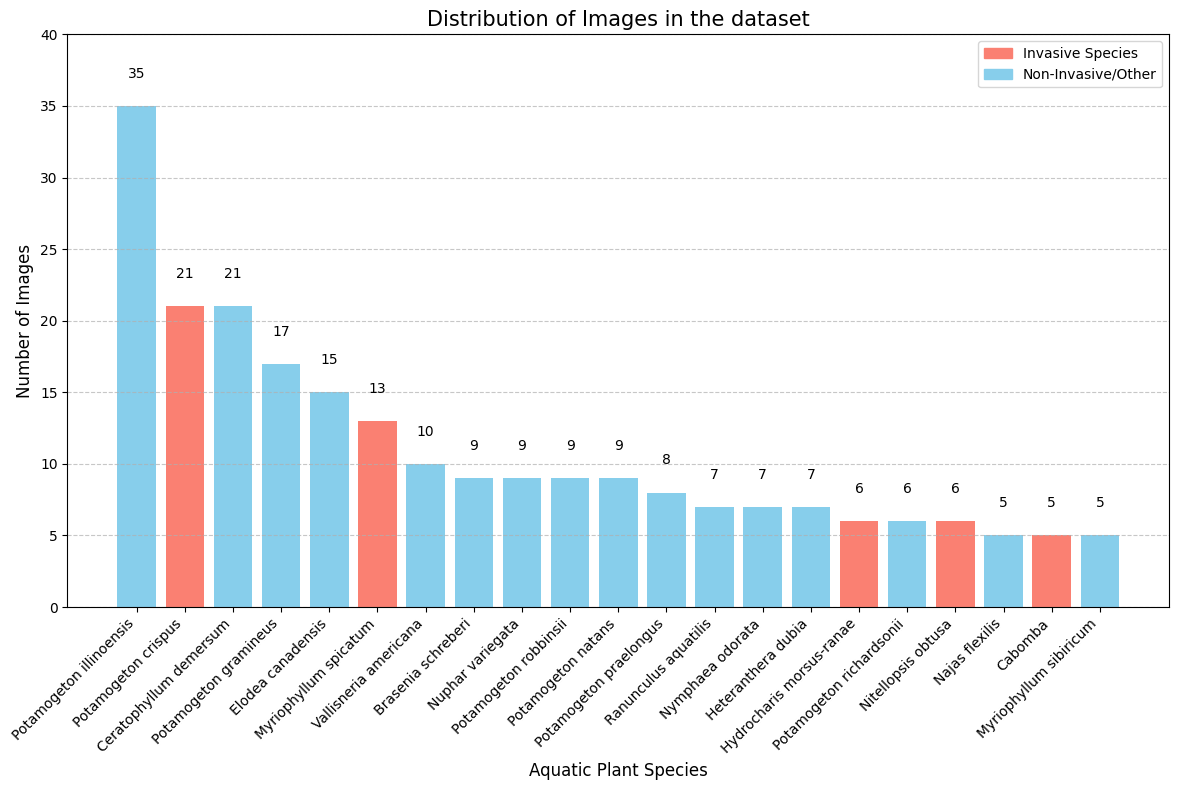

In [8]:
class_names_sorted = [item[0] for item in sorted_tuple]
class_counts_sorted = [item[1] for item in sorted_tuple]

colors = []
for cn in class_names_sorted:
    if cn in invasive_species:
        colors.append('salmon') 
    else:
        colors.append('skyblue') 

plt.figure(figsize=(12, 8)) 

# Create the bar plot
bars = plt.bar(class_names_sorted, class_counts_sorted, color=colors)

# Add counts on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05 * max(class_counts_sorted), int(yval), ha='center', va='bottom')

plt.xlabel("Aquatic Plant Species", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Images in the dataset", fontsize=15)
plt.xticks(rotation=45, ha="right", fontsize=10) 
plt.yticks(fontsize=10)
plt.ylim(0, 40)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 

invasive_patch = mpatches.Patch(color='salmon', label='Invasive Species')
non_invasive_patch = mpatches.Patch(color='skyblue', label='Non-Invasive/Other')
plt.legend(handles=[invasive_patch, non_invasive_patch], loc='upper right')

# plt.show()

# save the figure as svg
figures_dir = './figures'
name = 'simple_data_bar_plot.svg'

os.makedirs(figures_dir, exist_ok=True)

plt.savefig(os.path.join(figures_dir, name), format='svg', bbox_inches='tight')

- Extended the following classes with some online images:
  - Hydrocharis morsus-ranae
  - Potamogeton praelongus
  - Nymphaea odorata
  - Nuphar variegata

## Viewing some sample images

In [5]:
from PIL import Image

def display_sample_images(class_name, num_samples=5, figsize=(15, 6)):
    class_path = os.path.join(data_dir, class_name)
    images = os.listdir(class_path)
    sample_images = np.random.choice(images, size=min(num_samples, len(images)), replace=False)

    # Create a horizontal grid of images
    fig, axes = plt.subplots(1, len(sample_images), figsize=figsize)
    if len(sample_images) == 1:
        axes = [axes]  

    for ax, img_name in zip(axes, sample_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        
        wrapped_title = "\n".join([img_name[i:i+15] for i in range(0, len(img_name), 15)])
        resolution = f"{img.width}x{img.height}"
        
        ax.set_title(resolution, fontsize=10, loc='center')
        ax.text(0.5, -0.05, wrapped_title, fontsize=9, ha='center', va='top', transform=ax.transAxes)

    plt.suptitle(f"Sample Images from Class: {class_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

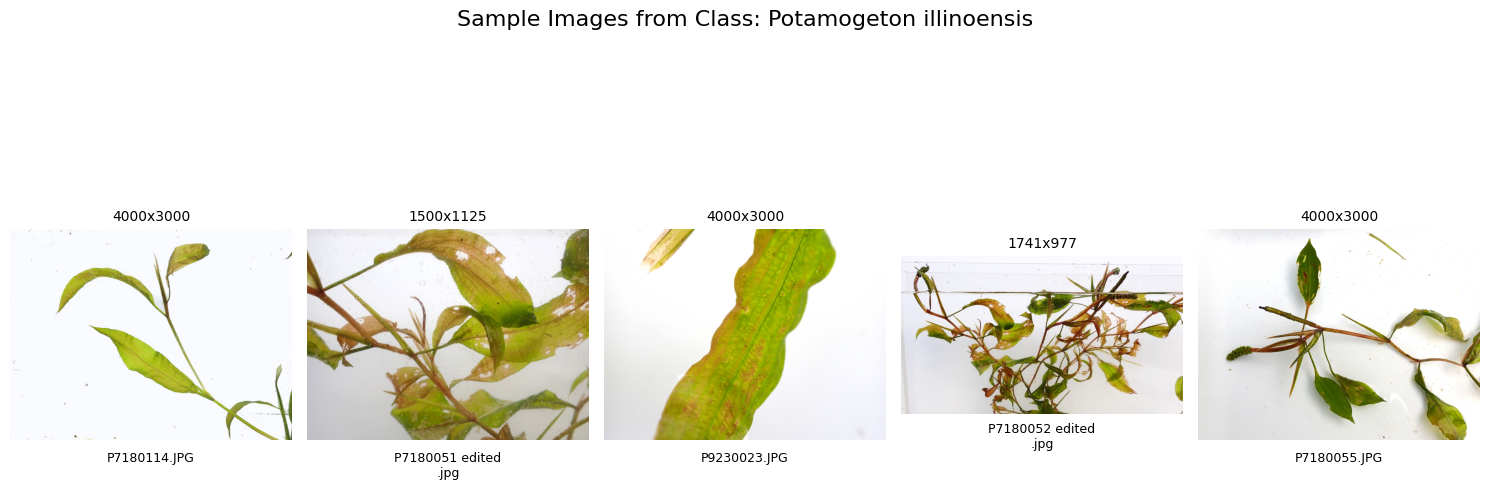

In [6]:
# Let's look at the most common class in our dataset
display_sample_images("Potamogeton illinoensis", num_samples=5)

In [7]:
# # All native species
# native_species = [name for name in class_names_sorted if name not in invasive_species]
# for native in native_species:
#     display_sample_images(native, num_samples=2, figsize=(4, 3))

In [8]:
# # All invasive species
# for invasive in invasive_species:
#     display_sample_images(invasive, num_samples=2, figsize=(4, 3))

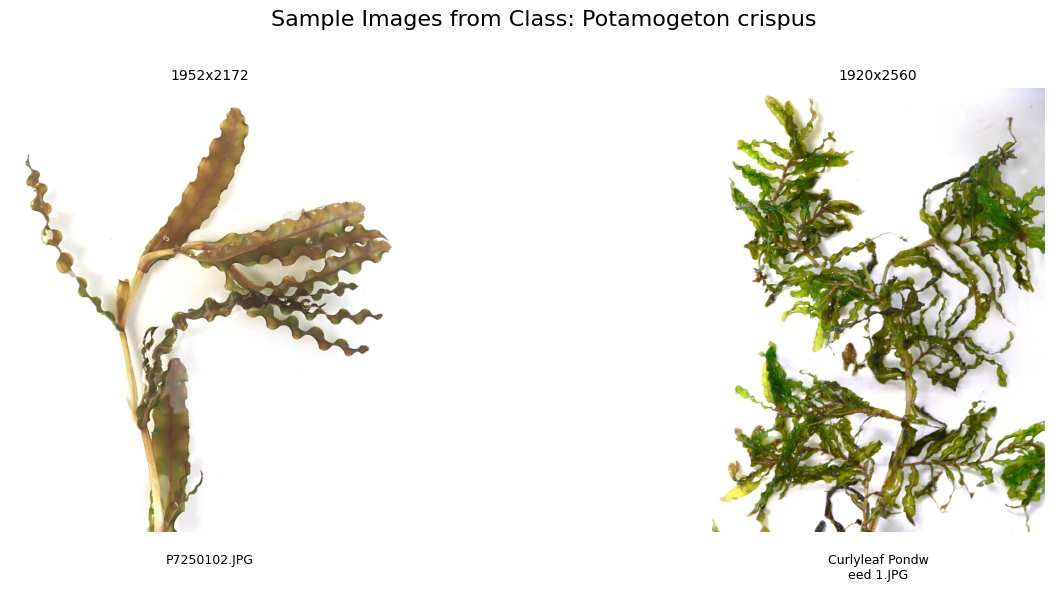

In [9]:
# Most common invasive species
display_sample_images("Potamogeton crispus", num_samples=2)

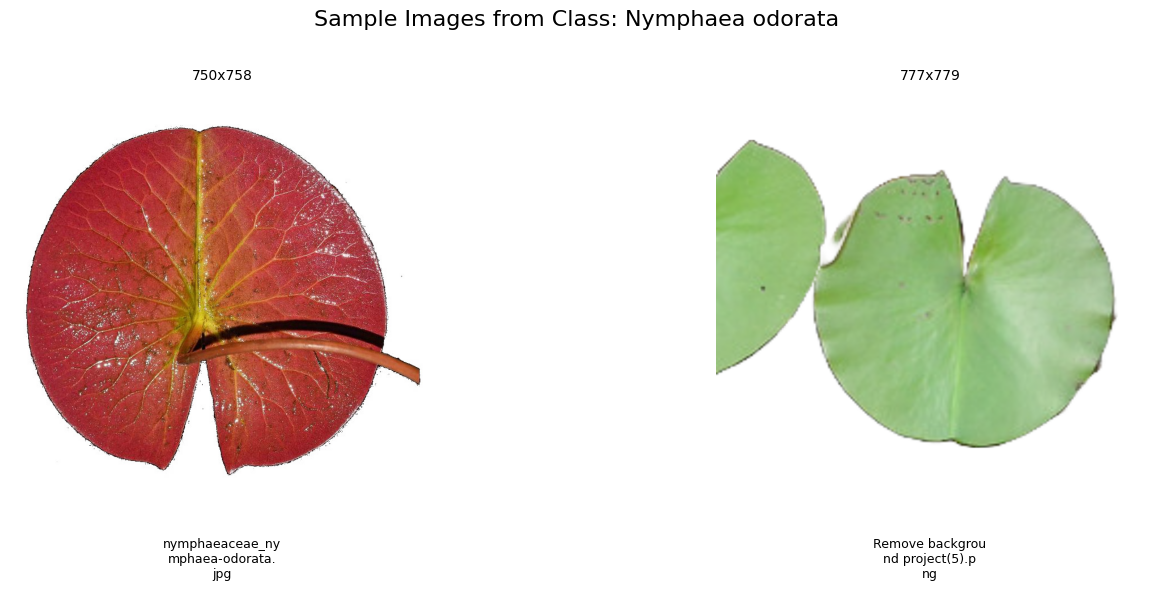

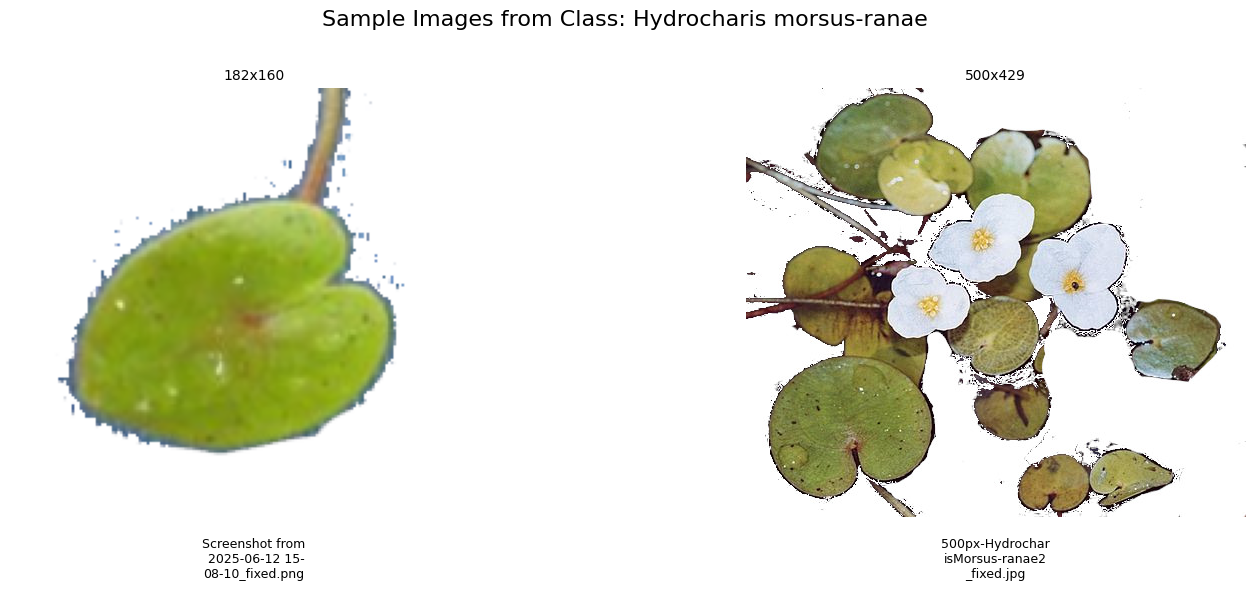

In [10]:
# Least common species
display_sample_images("Nymphaea odorata", 2)

# Least common Invasive species
display_sample_images("Hydrocharis morsus-ranae", 2)

### Observaitons
- Some are single round leaves that seem to be on the water surface
- Others are ferny, with smaller leaves that may be patched

## More dataset metadata analysis

In [11]:
headers = ["Image Name", "Class Name", "Is Native", "Width", "Height", "Aspect Ratio", "Resolution"]
data = []

for class_name in class_names_sorted:
    class_path = os.path.join(data_dir, class_name)
    for image_file in os.listdir(class_path):
        img_path = os.path.join(class_path, image_file)
        img = Image.open(img_path)
        width, height = img.size
        aspect_ratio = width / height
        is_native = class_name not in invasive_species
        
        num_channels = len(img.getbands())
        if num_channels !=3:
            print(f"Warning: {image_file} in {class_name} is not a standard RGB image (channels: {num_channels})")
            break

        data.append({
            "Image Name": image_file,
            "Class Name": class_name,
            "Is Native": is_native,
            "Width": width,
            "Height": height,
            "Aspect Ratio": aspect_ratio,
            "Resolution": f"{width}x{height}"
        })

images_df = pd.DataFrame(data, columns=headers)
images_df

,Image Name,Class Name,Is Native,Width,Height,Aspect Ratio,Resolution
0,P7180120.JPG,Potamogeton illinoensis,True,4000,3000,1.333333,4000x3000
1,P7180102.JPG,Potamogeton illinoensis,True,4000,3000,1.333333,4000x3000
2,P7180059.JPG,Potamogeton illinoensis,True,3732,2696,1.384273,3732x2696
3,P7180052 edited.jpg,Potamogeton illinoensis,True,1741,977,1.781986,1741x977
4,P7180061.JPG,Potamogeton illinoensis,True,4000,3000,1.333333,4000x3000
...,...,...,...,...,...,...,...
197,Nuphar variegata (spatterdock) leaf bottom_JL.jpg,Nuphar variegata,True,2944,2224,1.323741,2944x2224
198,Myriophyllum sibiricum (Northern watermilfoil)...,Myriophyllum sibiricum,True,2988,5312,0.562500,2988x5312
199,20200621_195746.jpg,Myriophyllum sibiricum,True,2988,5312,0.562500,2988x5312
200,Myriophyllum sibiricum (Northern watermilfoil)...,Myriophyllum sibiricum,True,2981,4120,0.723544,2981x4120


In [12]:
resolution_counts = images_df['Resolution'].value_counts().reset_index()

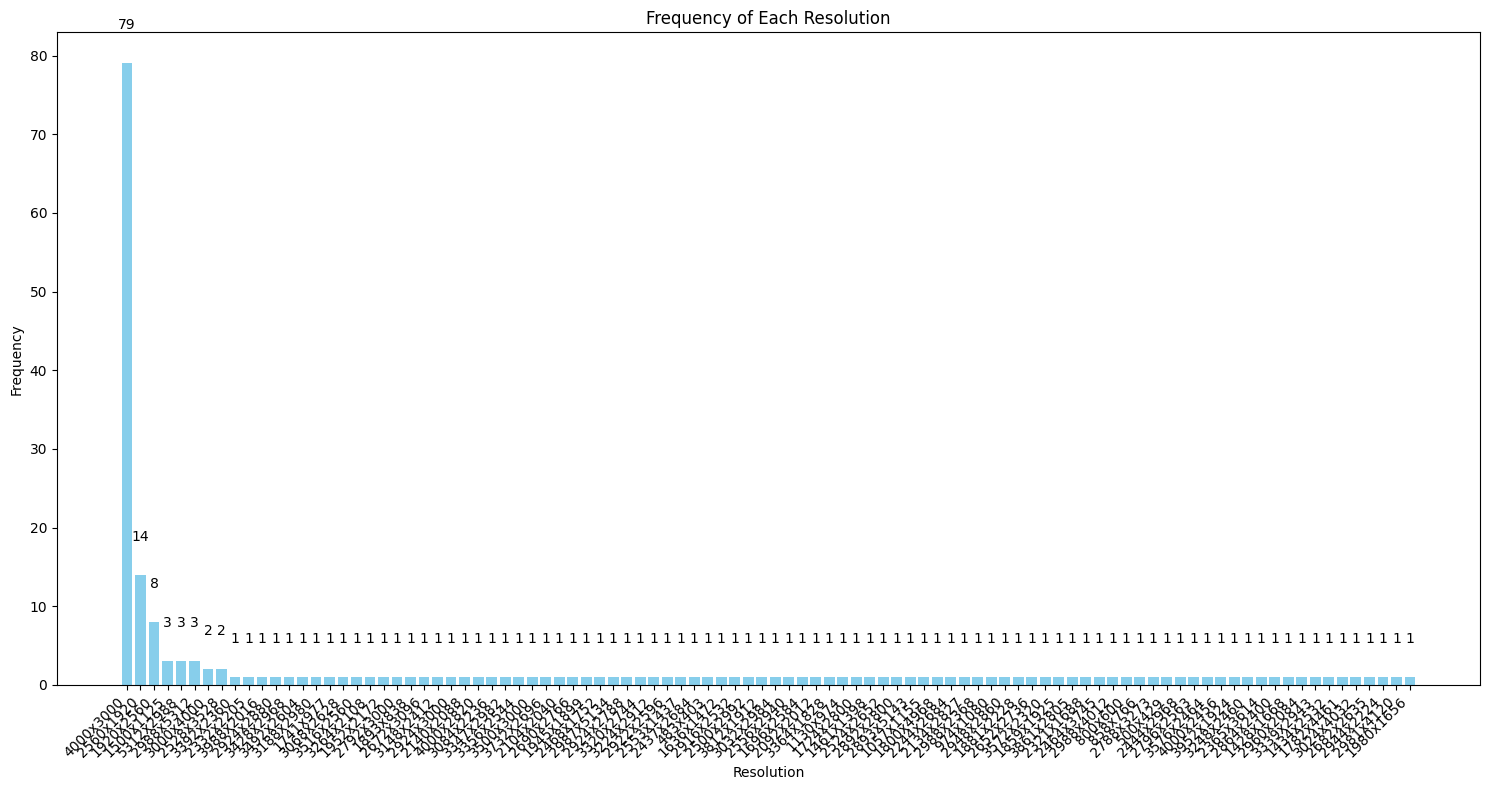

In [13]:
# Frequency of each Resolution
resolution_counts = images_df['Resolution'].value_counts().reset_index()
plt.figure(figsize=(15, 8))
plt.bar(resolution_counts['Resolution'], resolution_counts['count'], color='skyblue')

# Add counts on top of bars
for i, count in enumerate(resolution_counts['count']):
    plt.text(i, count + 0.05 * max(resolution_counts['count']), count, ha='center', va='bottom')

plt.xlabel("Resolution")
plt.ylabel("Frequency")
plt.title("Frequency of Each Resolution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

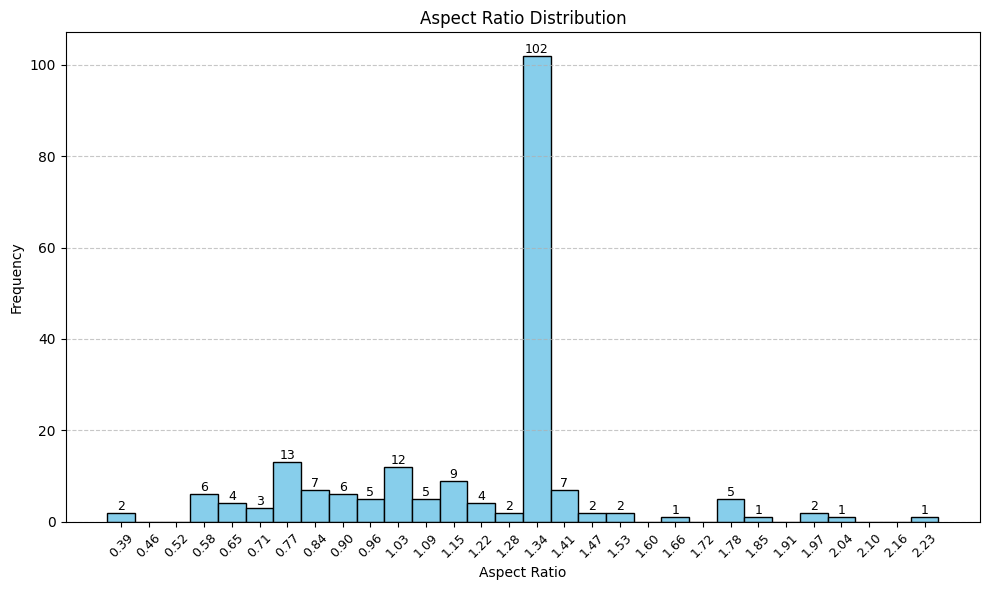

In [14]:
# Aspect Ratio Distribution
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(images_df['Aspect Ratio'], bins=30, color='skyblue', edgecolor='black')

bin_centers = 0.5 * (bins[:-1] + bins[1:])

for count, x in zip(n, bin_centers):
    if count > 0:
        plt.text(x, count, str(int(count)), ha='center', va='bottom', fontsize=9)

plt.xticks(bin_centers, [f"{x:.2f}" for x in bin_centers], rotation=45, fontsize=9)

plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.title("Aspect Ratio Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()